# In this notebook we implement the data augmentation methods used in the paper, create the model and train it. Afterwards, we save the model with the lowest validation loss across all 35 epochs and compute scoring metrics on validation and test sets.

In [1]:
from pathlib import Path
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import random
from torch import nn
from torch import optim
import torchmetrics
import matplotlib.pyplot as plt
train_folder = Path("../data/splits/train")
validation_folder = Path("../data/splits/validation")
test_folder = Path("../data/splits/test")
random.seed(42)
torch.manual_seed(42)
generator = torch.Generator().manual_seed(42)

## Gaussian Noise is implemented from scratch as it is not included in the pytorch transforms class. All other augmentations are implemented with existing methods.

In [2]:
import torch
##Create Gaussian Noise tranform since pytorch library does not include it.
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        return torch.clamp(tensor + noise, 0.0, 1.0)

In [3]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.01),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128))
])

evaluation_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [4]:
train_dataset = ImageFolder(
    root=train_folder,
    transform=train_transform
)
validation_dataset = ImageFolder(
    root=validation_folder,
    transform=evaluation_transform
)
test_dataset = ImageFolder(
    root=test_folder,
    transform=evaluation_transform
)

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=18,
    shuffle=True
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=18,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=18,
    shuffle=False
)

## Model architecture follows reported structe in the original paper

In [6]:
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.dropout = nn.Dropout(p=.5)
        
        self.fc1 = nn.Linear(
            in_features=128 * 16 * 16,
            out_features=128
        )
        
        self.fc2 = nn.Linear(
            in_features=128,
            out_features=1
        )
        self.sigmoid = nn.Sigmoid()

        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        
        return x.squeeze(dim=1)

In [7]:
model = BrainTumorCNN()

# Model training is done across 35 epochs. The model weights corresponding to the lowest validation BCELoss are saved for model evaluation. Classification metrics on the validation set are shown across all epochs during training. Training and validation loss and accuracy are graphed across all epochs.

In [8]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=.001)

In [9]:
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAUROC, BinaryROC
import copy

In [10]:
num_epochs = 35
best_validation_loss = float("inf")
train_loss_list = []
validation_loss_list = []
train_accuracy_list = []
validation_accuracy_list = []
best_model_weights = None
best_epoch = None
for epoch in range(num_epochs):
    # --------------------
    # Training
    # --------------------
    model.train()
    running_train_loss = 0.0
    train_accuracy_metric = BinaryAccuracy()
    for features, target in train_loader:
        target = target.float()

        optimizer.zero_grad()

        probabilities = model(features)
        loss = criterion(probabilities, target)
        
        loss.backward()
        optimizer.step()
        train_accuracy_metric.update(probabilities, target)
        running_train_loss += loss.item()
        
    train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(train_loss)
    train_accuracy_list.append(train_accuracy_metric.compute().item())
    # --------------------
    # Validation
    # --------------------
    model.eval()
    running_validation_loss = 0.0

    accuracy_metric = BinaryAccuracy()
    precision_metric = BinaryPrecision()
    recall_metric = BinaryRecall()
    f1_metric = BinaryF1Score()
    roc_metric = BinaryROC()
    auc_metric = BinaryAUROC()
    with torch.no_grad():
        for features, target in validation_loader:
            target_float = target.float()

            probabilities = model(features)
            loss = criterion(probabilities, target_float)

            running_validation_loss += loss.item()

            # TorchMetrics accepts probabilities and applies
            # the 0.5 threshold internally where appropriate.
            accuracy_metric.update(probabilities, target)
            precision_metric.update(probabilities, target)
            recall_metric.update(probabilities, target)
            f1_metric.update(probabilities, target)
            roc_metric.update(probabilities, target)
            # AUC must receive probabilities, not 0/1 predictions.
            auc_metric.update(probabilities, target)
    validation_loss = running_validation_loss / len(validation_loader)
    validation_loss_list.append(validation_loss)
    validation_accuracy = accuracy_metric.compute().item()
    validation_accuracy_list.append(validation_accuracy)
    validation_precision = precision_metric.compute().item()
    validation_recall = recall_metric.compute().item()
    validation_f1 = f1_metric.compute().item()
    validation_auc = auc_metric.compute().item()
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print(f"Best model updated at epoch {epoch + 1}")
    
    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Accuracy: {validation_accuracy:.4f} | "
        f"Precision: {validation_precision:.4f} | "
        f"Recall: {validation_recall:.4f} | "
        f"F1: {validation_f1:.4f} | "
        f"ROC-AUC: {validation_auc:.4f}"
    )

Best model updated at epoch 1
Epoch 01/35 | Train loss: 0.7189 | Validation loss: 0.6557 | Accuracy: 0.5000 | Precision: 0.5000 | Recall: 1.0000 | F1: 0.6667 | ROC-AUC: 0.8571
Best model updated at epoch 2
Epoch 02/35 | Train loss: 0.6748 | Validation loss: 0.5912 | Accuracy: 0.7500 | Precision: 0.8889 | Recall: 0.5714 | F1: 0.6957 | ROC-AUC: 0.8929
Best model updated at epoch 3
Epoch 03/35 | Train loss: 0.6545 | Validation loss: 0.5839 | Accuracy: 0.7500 | Precision: 0.7333 | Recall: 0.7857 | F1: 0.7586 | ROC-AUC: 0.8827
Best model updated at epoch 4
Epoch 04/35 | Train loss: 0.6280 | Validation loss: 0.4806 | Accuracy: 0.7857 | Precision: 0.7000 | Recall: 1.0000 | F1: 0.8235 | ROC-AUC: 0.8878
Epoch 05/35 | Train loss: 0.6201 | Validation loss: 0.5435 | Accuracy: 0.7857 | Precision: 0.7222 | Recall: 0.9286 | F1: 0.8125 | ROC-AUC: 0.8929
Epoch 06/35 | Train loss: 0.5924 | Validation loss: 0.4865 | Accuracy: 0.7500 | Precision: 0.6667 | Recall: 1.0000 | F1: 0.8000 | ROC-AUC: 0.8929
Best

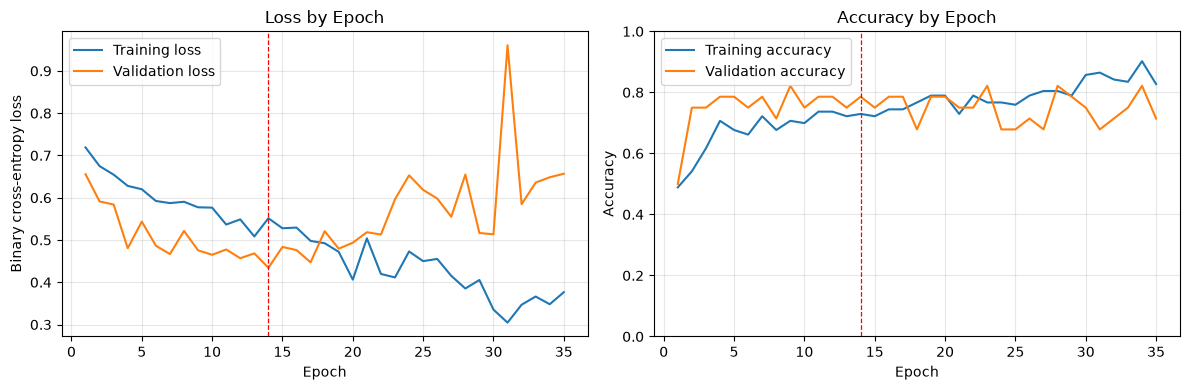

In [11]:
epochs = range(1, len(train_loss_list) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_loss_list, label="Training loss")
axes[0].plot(epochs, validation_loss_list, label="Validation loss")
axes[0].set_title("Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, train_accuracy_list, label="Training accuracy")
axes[1].plot(epochs, validation_accuracy_list, label="Validation accuracy")
axes[1].set_title("Accuracy by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[0].axvline(
    x=best_epoch,
    color="red",
    linestyle="--",
    linewidth=.9,
    label=f"Best epoch ({best_epoch})"
)

axes[1].axvline(
    x=best_epoch,
    color="red",
    linestyle="--",
    linewidth=.9,
    label=f"Best epoch ({best_epoch})"
)
fig.savefig(
    "../figures/training_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

## Classification metrics are calculated for the saved model across the validation and test set. ROC-AUC curves and confusion matrices are also generated for the validation and test sets.

In [12]:
from torchmetrics.classification import BinaryConfusionMatrix
model.load_state_dict(best_model_weights)
model.eval()

best_roc_metric = BinaryROC()
best_auc_metric = BinaryAUROC()
best_accuracy_metric = BinaryAccuracy()
best_precision_metric = BinaryPrecision()
best_recall_metric = BinaryRecall()
best_f1_metric = BinaryF1Score()
running_best_loss=0
best_confusion_matrix_metric = BinaryConfusionMatrix(threshold=0.5)

with torch.no_grad():
    for features, target in validation_loader:
        probabilities = model(features)
        running_best_loss += criterion(probabilities,target.float())
        best_roc_metric.update(probabilities, target)
        best_auc_metric.update(probabilities, target)
        best_confusion_matrix_metric.update(probabilities, target)
        best_accuracy_metric.update(probabilities, target)   
        best_precision_metric.update(probabilities, target)
        best_recall_metric.update(probabilities, target)
        best_f1_metric.update(probabilities, target)
        best_auc_metric.update(probabilities, target)

best_loss = running_best_loss / len(validation_loader)
best_fpr, best_tpr, best_thresholds = best_roc_metric.compute()
best_accuracy = best_accuracy_metric.compute().item()
best_precision = best_precision_metric.compute().item()
best_recall = best_recall_metric.compute().item()
best_f1 = best_f1_metric.compute().item()
best_auc = best_auc_metric.compute().item()
best_confusion_matrix = best_confusion_matrix_metric.compute()

print(
        f"Best Epoch ({best_epoch}): BCELoss: {best_loss:.4f} | "
        f"Accuracy: {best_accuracy:.4f} | "
        f"Precision: {best_precision:.4f} | "
        f"Recall: {best_recall:.4f} | "
        f"F1: {best_f1:.4f} | "
        f"ROC-AUC: {best_auc:.4f}"
    )

Best Epoch (14): BCELoss: 0.4342 | Accuracy: 0.7857 | Precision: 0.7222 | Recall: 0.9286 | F1: 0.8125 | ROC-AUC: 0.8571


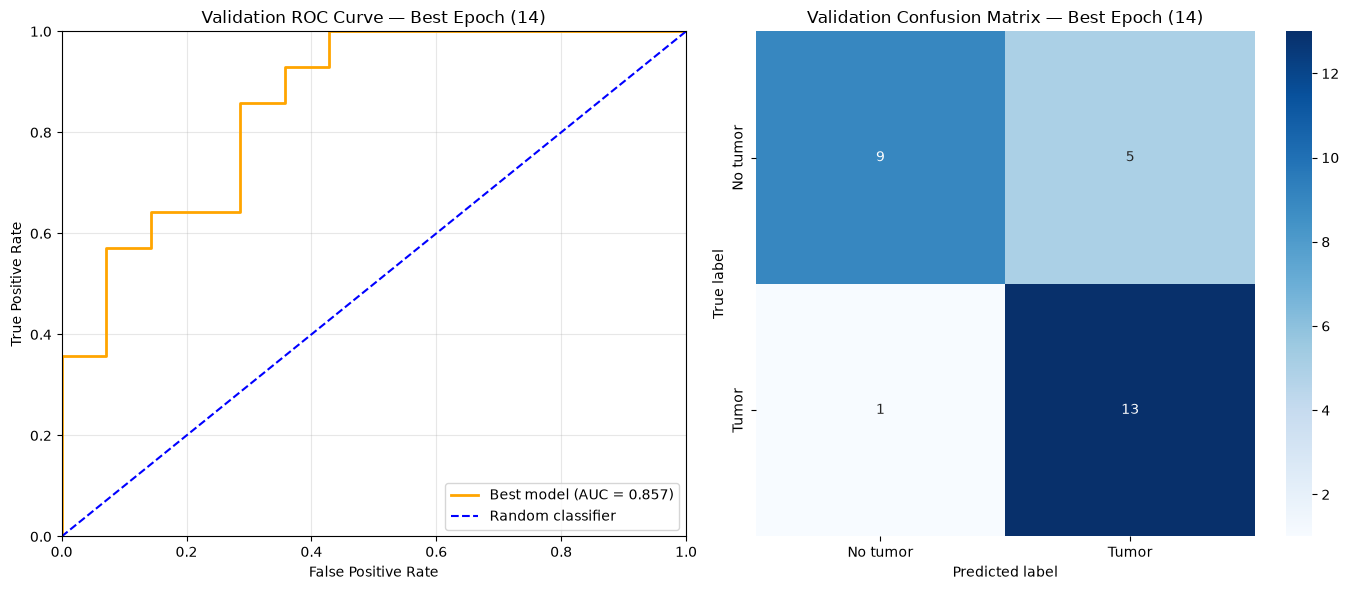

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
axes[0].plot(
    best_fpr.cpu(),
    best_tpr.cpu(),
    linewidth=2,
    color="orange",
    label=f"Best model (AUC = {best_auc:.3f})"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="blue",
    label="Random classifier"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"Validation ROC Curve — Best Epoch ({best_epoch})")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Confusion matrix
sns.heatmap(
    best_confusion_matrix.cpu().numpy(),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No tumor", "Tumor"],
    yticklabels=["No tumor", "Tumor"],
    ax=axes[1]
)

axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title(
    f"Validation Confusion Matrix — Best Epoch ({best_epoch})"
)
fig.savefig(
    "../figures/validation_roc_conf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [14]:
#compute for test set
test_roc_metric = BinaryROC()
test_auc_metric = BinaryAUROC()
test_accuracy_metric = BinaryAccuracy()
test_precision_metric = BinaryPrecision()
test_recall_metric = BinaryRecall()
test_f1_metric = BinaryF1Score()
running_test_loss=0
test_confusion_matrix_metric = BinaryConfusionMatrix(threshold=0.5)
with torch.no_grad():
    for features, target in test_loader:
        probabilities = model(features)
        running_test_loss += criterion(probabilities,target.float())
        test_roc_metric.update(probabilities, target)
        test_auc_metric.update(probabilities, target)
        test_confusion_matrix_metric.update(probabilities, target)
        test_accuracy_metric.update(probabilities, target)   
        test_precision_metric.update(probabilities, target)
        test_recall_metric.update(probabilities, target)
        test_f1_metric.update(probabilities, target)
        # AUC must receive probabilities, not 0/1 predictions.
        test_auc_metric.update(probabilities, target)
test_loss = running_test_loss / len(test_loader)
test_fpr, test_tpr, test_thresholds = test_roc_metric.compute()
test_accuracy = test_accuracy_metric.compute().item()
test_precision = test_precision_metric.compute().item()
test_recall = test_recall_metric.compute().item()
test_f1 = test_f1_metric.compute().item()
test_auc = test_auc_metric.compute().item()
test_confusion_matrix = test_confusion_matrix_metric.compute()

print(
        f"Test: BCELoss: {test_loss:.4f} | "
        f"Accuracy: {test_accuracy:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f} | "
        f"F1: {test_f1:.4f} | "
        f"ROC-AUC: {test_auc:.4f}"
    )

Test: BCELoss: 0.4424 | Accuracy: 0.8571 | Precision: 0.8125 | Recall: 0.9286 | F1: 0.8667 | ROC-AUC: 0.8776


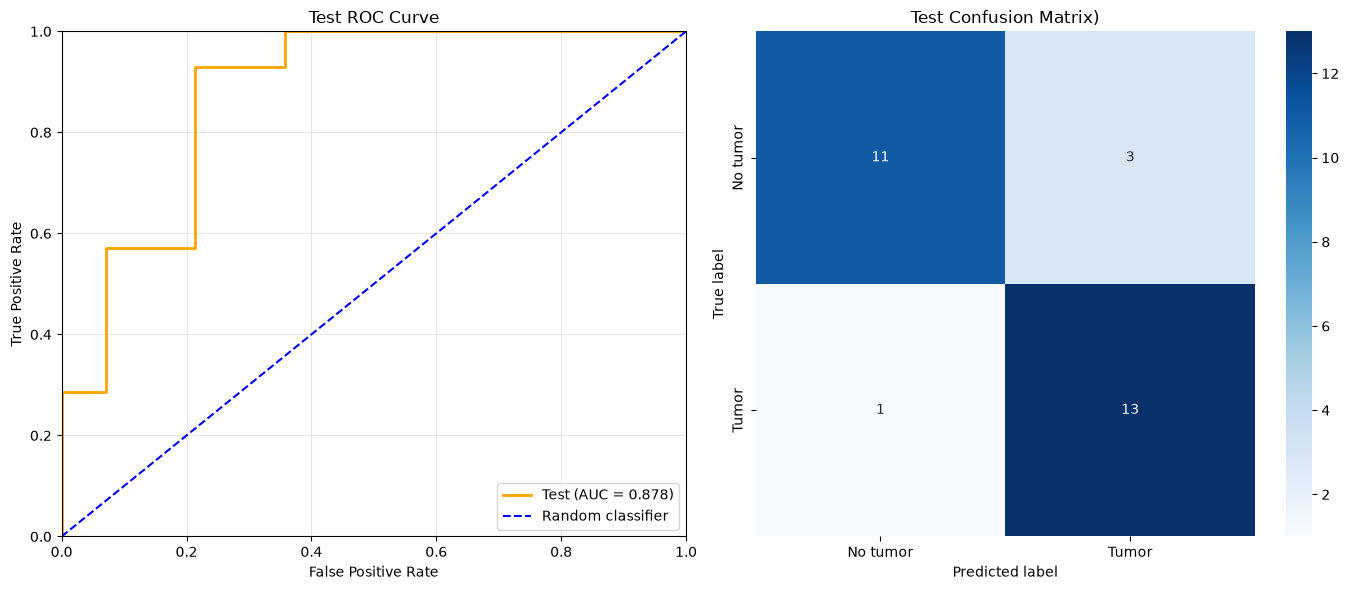

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
axes[0].plot(
    test_fpr.cpu(),
    test_tpr.cpu(),
    linewidth=2,
    color="orange",
    label=f"Test (AUC = {test_auc:.3f})"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="blue",
    label="Random classifier"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Test ROC Curve")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Confusion matrix
sns.heatmap(
    test_confusion_matrix.cpu().numpy(),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No tumor", "Tumor"],
    yticklabels=["No tumor", "Tumor"],
    ax=axes[1]
)

axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title("Test Confusion Matrix)")

fig.savefig(
    "../figures/test_roc_conf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [16]:
model_path = Path("../models/best_model.pt")
model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(best_model_weights, model_path)